# Predation-Controlled Pest Density

**Methods:** Analytical equilibria via Cardano's formula, Euler integration, stability classification; NumPy, Matplotlib

### Overview
This notebook investigates how predation controls pest density by comparing the model's equilibrium points with numerical solutions using the Euler method.

---

### Equilibrium Points
The four equilibrium points of the model are derived mathematically to identify the possible steady states of the pest population.

The predation controls the density of pests equation to be $f(x)$, which is:

$$
f(x) = \frac{dx}{dt} = rx\left(1-\frac{x}{K}\right) - \frac{Px^{2}}{1+x^{2}}
$$

In order to find equilibrium points from the model $f(x)$ is assumed to be 0 (no change in $x$ overtime)
Let's derive the equation:

$$
f(x) = \frac{Krx(1+x^{2})-rx^{2}(1+x^{2})-KPx^{2}}{K(1+x^{2})} = 0
$$

$$
\frac{Krx+Krx^{3}-rx^{2}-rx^{4}-KPx^{2}}{K(1+x^{2})} = 0
$$

$$
\frac{-rx^{4}+Krx^{3}-(r+KP)x^{2}+Krx}{K(1+x^{2})} = 0
$$

$$
\frac{x(-rx^{3}+Krx^{2}-(r+KP)x+Kr)}{K(1+x^{2})} = 0
$$

Now we can get the first trivial $x = 0$ for our first equilibrium points.
Then, we can focus on $-rx^{3}+Krx^{2}-(r+KP)x+Kr$ terms to be 0 and use Cardano's formula:

$$
-rx^{3} + Krx^{2} - (r + KP)x + Kr = 0
$$

Factor out $-r$:

$$
x^{3} - Kx^{2} + \left(1 + \frac{KP}{r}\right)x - K = 0
$$

Now depress the cubic using the substitution:

$$
x = y + \frac{K}{3}
$$

This transforms the equation into:

$$
y^{3} + py + q = 0
$$

where

$$
p = \left(1 + \frac{KP}{r}\right) - \frac{K^{2}}{3},
\qquad
q = \frac{2(-K)^{3}}{27} - \frac{(-K)\left(1+\dfrac{KP}{r}\right)}{3} - K.
$$

Expand the equation:
$$
p = 1 + \frac{KP}{r} - \frac{K^{2}}{3},
\qquad
q = -\frac{2K^{3}}{27} + \frac{K}{3}\left(1+\frac{KP}{r}\right) - K.
$$

Compute the discriminant
$$
\Delta = \left(\frac{q}{2}\right)^{2} + \left(\frac{p}{3}\right)^{3}
$$

and the Cardano quantities
$$
A = -\frac{q}{2} + \sqrt{\Delta},
\qquad
B = -\frac{q}{2} - \sqrt{\Delta}.
$$

A principal solution of the depressed cubic is
$$
y = \sqrt[3]{A} + \sqrt[3]{B}
$$

so that
$$
x = \sqrt[3]{A} + \sqrt[3]{B} + \frac{K}{3}.
$$

Using the cube roots of unity
$$
\omega = e^{2\pi i/3} = \frac{-1 + i\sqrt{3}}{2},
\qquad
\omega^{2} = e^{4\pi i/3} = \frac{-1 - i\sqrt{3}}{2},
$$

Thus the three Cardano roots of the cubic are:

$$
x_{k} = \omega^{k}\sqrt[3]{A}
      + \omega^{2k}\sqrt[3]{B}
      + \frac{K}{3},
\qquad
k = 0,1,2.
$$

**Hence, we can conclude that**

$$
-rx^{3} + Krx^{2} - (r + KP)x + Kr = 0
$$

are given by
$$
x_{k}=\omega^{k}\sqrt[3]{A}+\omega^{2k}\sqrt[3]{B}+\frac{K}{3},
\qquad k = 0,1,2.
$$


**Therefore, we can conclude that** 4 equlibrium point of the roots is $0$ and $\omega^{k}\sqrt[3]{A}+\omega^{2k}\sqrt[3]{B}+\frac{K}{6}$ where $k = 0,1,2$

---



#### Effect of $P/r$ and Initial Condition

The Euler method is used to investigate how the ratio $P/r$ and the initial condition $x_0$ affect the converged value of $x$.

#### Importing necessary modules and defining shared parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
r = 1
K = 10
P_values = [0, 0.5, 1, 2, 4]
x0_values = [0, 0.5, 2, 2.5, 5, 8]
dt = 0.01
t = np.arange(0.0,15.0+dt,dt)

#### Define the functions of equation and Euler Method

In [2]:
def dXdt(t,X,P):
  return r*X*(1-X/K)-((P*X*X)/(X*X+1))

def euler(x0, P):
  X = np.zeros_like(t)
  X[0] = x0
  for n in range(len(t)-1):
    X[n+1] = X[n] + dt * dXdt(t[n], X[n], P)
  return X

def cbrt(z):
  tol = 1e-12
  if abs(z.imag) < tol:
    zr = z.real
    if zr >= 0:
      return zr**(1/3)
    else:
      return - (abs(zr)**(1/3))
  else:
    return cmath.exp(cmath.log(z) / 3)

def cardano_roots(r, K, P):
  p = 1 + (K*P)/r - (K**2)/3
  q = -(2*K**3)/27 + (K/3)*(1 + (K*P)/r) - K

  Delta = (q/2)**2 + (p/3)**3

  A = -q/2 + cmath.sqrt(Delta)
  B = -q/2 - cmath.sqrt(Delta)


  C = cbrt(A)
  D = cbrt(B)

  omega = complex(-0.5,  cmath.sqrt(3)/2)
  omega2 = complex(-0.5, -cmath.sqrt(3)/2)

  roots = []
  for k in range(3):
    x_k = (omega**k)*C + (omega2**k)*D + K/3
    roots.append(x_k)

  return roots

#### Creating Dictionary store different x initial and P value
where Keys is x initial and P value stored in tuple.

Items is a list store x value in sequence from `t = 0` to `t = 15`, with step of `dt = 0.01`

In [3]:
results = {}

for x0 in x0_values:
  for P in P_values:
    results[(x0, P)] = euler(x0, P)

# for key, value in results.items():
#   print(f"(x_0, P): {key}, X over time: {value}")

#### Plot the graph

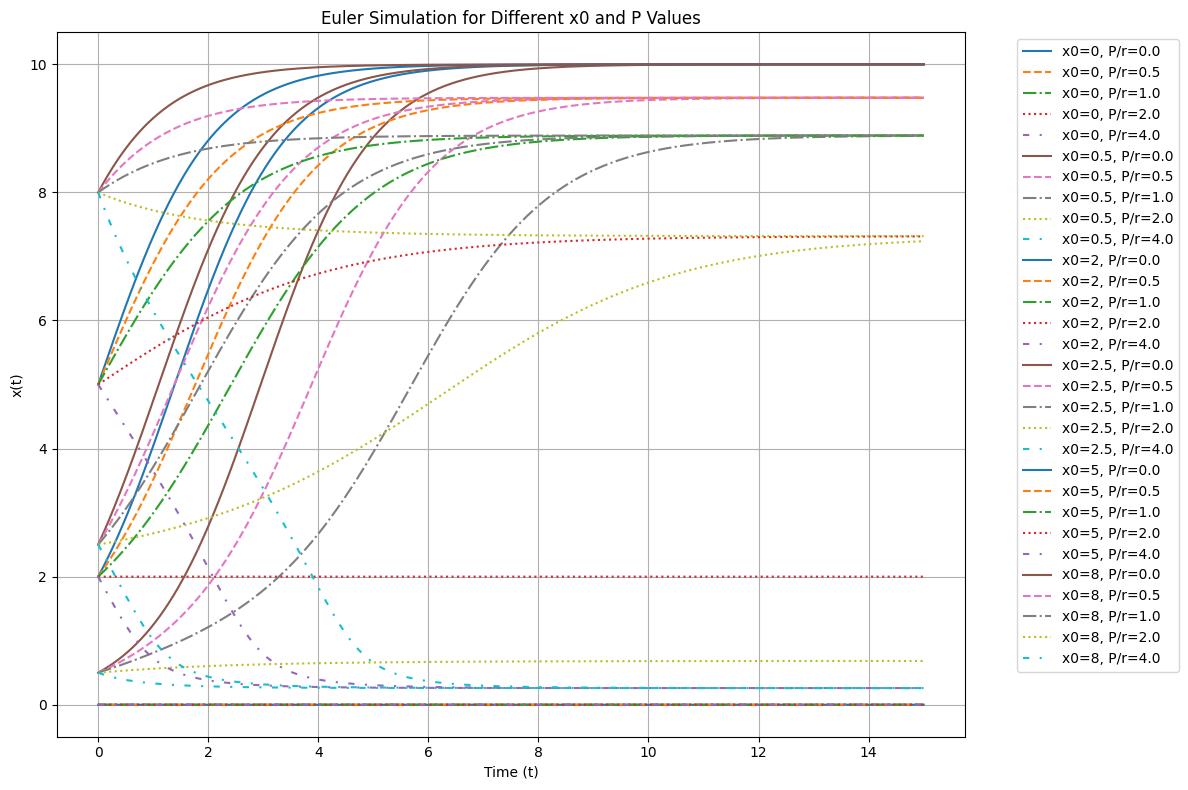

In [4]:
line_styles = {
    0:      "-",
    0.5:    "--",
    1:      "-.",
    2:      ":",
    4:      (0, (3, 5, 1, 5))
}

plt.figure(figsize=(12, 8))
for (x0, P), X_vals in results.items():
  style = line_styles.get(P, "-")
  plt.plot(t, X_vals, linestyle=style, label=f"x0={x0}, P/r={P/r}")
plt.xlabel("Time (t)")
plt.ylabel("x(t)")
plt.title("Euler Simulation for Different x0 and P Values")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

---

#### Comparison with Equilibrium Points
The converged values obtained from the Euler method are compared with the mathematically derived equilibrium points to examine their agreement.


In [5]:
for P in P_values:
    print(f"\nP/r = {P/r}")
    roots_P = cardano_roots(r, K, P)
    for i, root in enumerate(roots_P):
        print(f"  x_{i} = {root}")


P/r = 0.0
  x_0 = (10+0j)
  x_1 = (4.440892098500626e-16+0.9999999999999996j)
  x_2 = (8.881784197001252e-16-0.9999999999999996j)

P/r = 0.5
  x_0 = (9.47828573273229+0j)
  x_1 = (0.2608571336338552+0.9934770555105508j)
  x_2 = (0.26085713363385565-0.9934770555105508j)

P/r = 1.0
  x_0 = (8.889084119894875+0j)
  x_1 = (0.555457940052563+0.9035716731123484j)
  x_2 = (0.5554579400525639-0.9035716731123484j)

P/r = 2.0
  x_0 = (7.3166247903554+0j)
  x_1 = (0.6833752096446006+0j)
  x_2 = (2.000000000000001+0j)

P/r = 4.0
  x_0 = (0.2599562261176058+0j)
  x_1 = (4.870021886941197+3.8406902763741475j)
  x_2 = (4.870021886941197-3.8406902763741475j)


---

### Discussion

Since Cubic equations will get either:
- 3 distinct real roots $; \Delta > 0$
- 1 real root and 2 non-real complex conjugate roots $; \Delta < 0$

the behaviour of the system depends directly on which case occurs for each value of $P/r$.

From the Cardano calculation, the cases `P/r = 0.0, 0.5, 1.0, 4.0` all satisfy $\Delta > 0$. Therefore the cubic has only one real equilibrium (besides the trivial equilibrium at `x = 0`). Since `x = 0` is an unstable fixed point for the logistic-harvesting dynamics, every trajectory with $x_{0}>0$ eventually moves away from $0$ and converges to the single stable real root.

The only case where the behaviour changes is at `P/r = 2.0`. Here the cubic satisﬁes $\Delta < 0$, giving three real roots:

The roots at $0$ and $2$ are unstable, while the remaining two are stable. Additionally, the trajectory doesn't necessarily converge to the "closest" root. Instead, they converge to the stable equilibrium that lies in the same zone, which is determined by the sign of $f(x)$ between the unstable equilibrium point. Hence initial conditions with $x_0 > 2$ flow upward to $7.32$, while those with $0 < x_0 < 2$ flow downward to $0.68$.

Finally, the only case where the graph will converge to the unstable equilibrium point is when the initial x is the same as those unstable equilibrium point i.e. $x_0 = 0$ or $x_0 = 2$ for `P/r = 2` case.

### Reference

https://en.wikipedia.org/wiki/Cubic_equation (for Cardano's method)